## 1. Librerías

In [18]:
import pandas as pd
import numpy as np
import random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga y Procesamiento de Datos

In [19]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")
print(f"El dataset cuenta con {df.shape[1]} features")

Total de observaciones: 77
Rango temporal: 2025-01-06 a 2025-04-30
El dataset cuenta con 61 features


### 2.1. Limpieza de valores nulos

In [20]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

Filas con NA en 'merval': 0


### 2.2. Separación de variables

In [21]:
# Separación de variables predictoras y objetivo
y = df["merval"]
X = df.drop(columns=["merval"])

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (77, 60)
Shape de y: (77,)


## 3. División Train-Test

In [22]:
# División temporal (80-20)
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (61, 60)
Test shape: (16, 60)


## 4. Feature Selection - Selección de Top Features

Para abordar el problema de dimensionalidad y reducir el ruido para el LSTM, seleccionamos las top 12 features más importantes usando Random Forest.

In [23]:
# Entrenar un modelo simple para obtener importancia de features
# Usamos Random Forest con configuración conservadora
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)

# Obtener importancia de features
feature_importance = pd.Series(
    rf_selector.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features más importantes:")
print(feature_importance.head(15))


Top 15 features más importantes:
merval_cierre                      0.178296
merval_apertura_std20              0.157304
tc_mayorista_std20                 0.109336
emae_tendencia_ciclo_ma_5          0.103819
tc_minorista_std20                 0.070966
merval_cierre_std20                0.056455
gobernanza_mean                    0.052432
badlar_ma_5                        0.047308
merval_maximo                      0.032226
inflacion_lag2                     0.029369
sector_Educación_prop_true_lag1    0.020651
emae_tendencia_ciclo_lag2          0.015510
bonos_soberanos_mean_lag2          0.011427
m2_transaccional_pct3              0.010420
tasa_prestamos_personales_ma_3     0.008084
dtype: float64


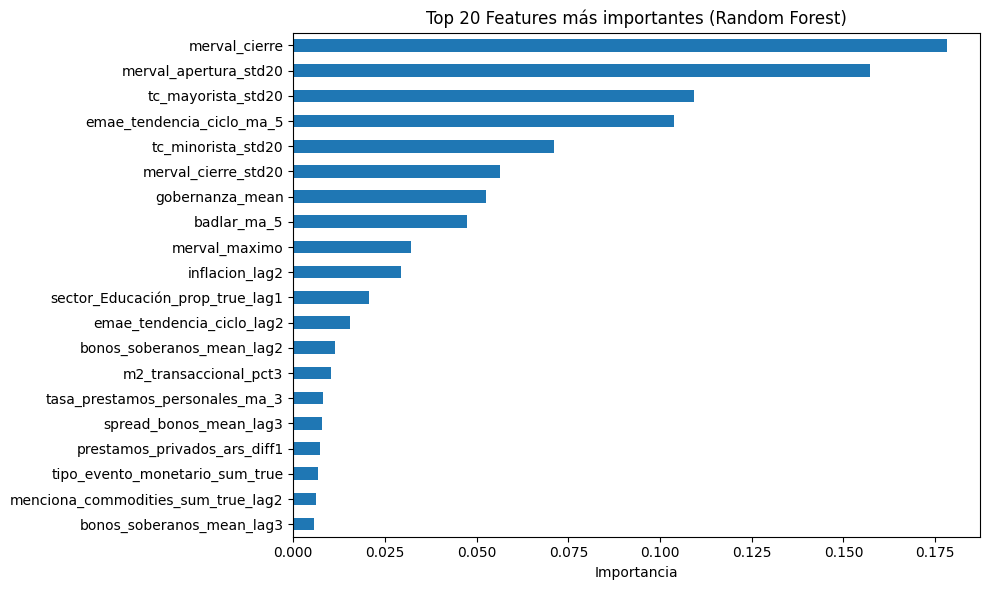

In [24]:
# Visualizar importancia de features
plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 20 Features más importantes (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [25]:
# Seleccionar top N features
N_FEATURES = 12  # Cambiar a 15 si se desea probar con más features

selected_features = feature_importance.head(N_FEATURES).index.tolist()

print(f"\nSeleccionadas {N_FEATURES} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Filtrar datasets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

print(f"\nNuevo train shape: {X_train_fs.shape}")
print(f"Nuevo test shape: {X_test_fs.shape}")
print(f"\nNuevo ratio observaciones/features: {X_train_fs.shape[0] / X_train_fs.shape[1]:.2f}")


Seleccionadas 12 features:
1. merval_cierre
2. merval_apertura_std20
3. tc_mayorista_std20
4. emae_tendencia_ciclo_ma_5
5. tc_minorista_std20
6. merval_cierre_std20
7. gobernanza_mean
8. badlar_ma_5
9. merval_maximo
10. inflacion_lag2
11. sector_Educación_prop_true_lag1
12. emae_tendencia_ciclo_lag2

Nuevo train shape: (61, 12)
Nuevo test shape: (16, 12)

Nuevo ratio observaciones/features: 5.08


### 4.1. Normalización de features seleccionadas

In [26]:
# Convertir a numpy arrays
X_train_np = X_train_fs.values
X_test_np = X_test_fs.values
y_train_np = y_train.values
y_test_np = y_test.values

# Normalizar features (importante para redes neuronales)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_np)
X_test_scaled = scaler_X.transform(X_test_np)
y_train_scaled = scaler_y.fit_transform(y_train_np.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_np.reshape(-1, 1)).flatten()

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (61, 12)
X_test_scaled shape: (16, 12)


## 5. Creación de Secuencias Temporales

In [27]:
def create_sequences(X, y, time_steps=3):
    """
    Crea secuencias temporales para LSTM.
    
    Args:
        X: Features de entrada
        y: Variable objetivo
        time_steps: Número de pasos temporales a considerar
    
    Returns:
        X_seq: Secuencias de features (samples, time_steps, features)
        y_seq: Valores objetivo correspondientes
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    
    return np.array(X_seq), np.array(y_seq)

In [28]:
# Crear secuencias temporales
TIME_STEPS = 3  # Reducir a 3 días para maximizar muestras disponibles

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"Train sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

Train sequences shape: (58, 3, 12)
Test sequences shape: (13, 3, 12)


## 6. Construcción del Modelo LSTM

In [29]:
# Arquitectura del modelo - Simplificada para dataset pequeño con feature selection
model = Sequential([
    # Capa LSTM con pocas unidades (menos features = menos parámetros necesarios)
    LSTM(16, return_sequences=False, input_shape=(TIME_STEPS, N_FEATURES)),
    Dropout(0.4),  # Dropout alto para regularización agresiva
    
    Dense(4, activation='relu'),  # Capa densa pequeña
    Dropout(0.3),
    
    Dense(1)
])

# Compilar modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 16)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,929 (7.54 KB)

 Trainable params: 1,929 (7.54 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento del Modelo

In [30]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Entrenar modelo
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=200,
    batch_size=8,
    validation_split=0.25,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.2652 - mae: 0.9772 - val_loss: 0.6574 - val_mae: 0.5892 - learning_rate: 3.0000e-04
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4944 - mae: 1.0322 - val_loss: 0.6390 - val_mae: 0.5790 - learning_rate: 3.0000e-04
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2945 - mae: 0.9968 - val_loss: 0.6221 - val_mae: 0.5690 - learning_rate: 3.0000e-04
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9067 - mae: 0.8335 - val_loss: 0.6080 - val_mae: 0.5595 - learning_rate: 3.0000e-04
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8965 - mae: 0.8096 - val_loss: 0.5932 - val_mae: 0.5482 - learning_rate: 3.0000e-04
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9034 - mae: 0.8273 - val_loss: 0.5803 - val_mae: 0.5380 - learning_rate: 3.0000e-04
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9642 - mae: 0.8305 - val_loss: 0.5687 - val_mae: 0.5286 - learning_rate: 3.0000e-04
Epoch 8/20

### 7.1. Visualización del entrenamiento

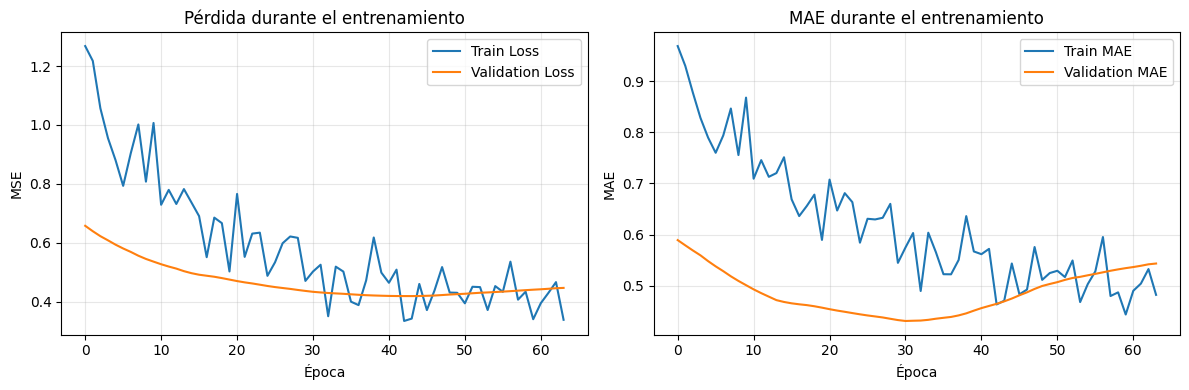

In [31]:
# Gráfico de pérdida durante entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluación en Test Set

### 8.1. Métricas de desempeño

In [32]:
# Predicciones en escala normalizada
y_pred_scaled = model.predict(X_test_seq)

# Desnormalizar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_original = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Calcular métricas
rmse = root_mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse_rel = rmse / y_test_original.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 355591.3007
Holdout R²:   -22.1612
Error relativo (holdout): 16.17%


### 8.2. Visualización de predicciones

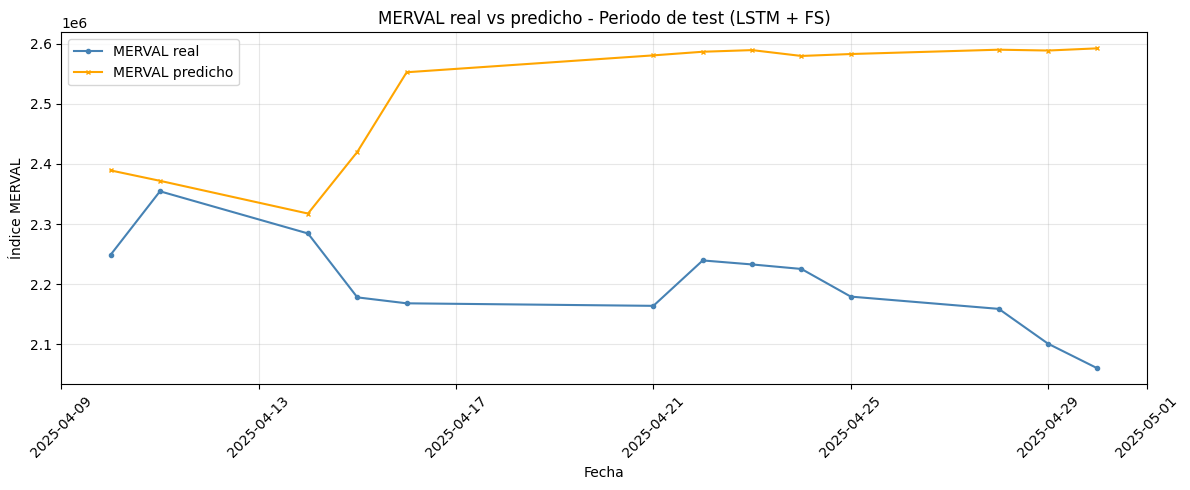

In [33]:
# Crear índices para graficar
test_indices = df.index[train_size + TIME_STEPS:]

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_indices.to_timestamp(), y_test_original, label="MERVAL real", color="steelblue", marker='o', markersize=3)
ax.plot(test_indices.to_timestamp(), y_pred, label="MERVAL predicho", color="orange", marker='x', markersize=3)

ax.set_title("MERVAL real vs predicho - Periodo de test (LSTM + FS)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3. Análisis de residuales

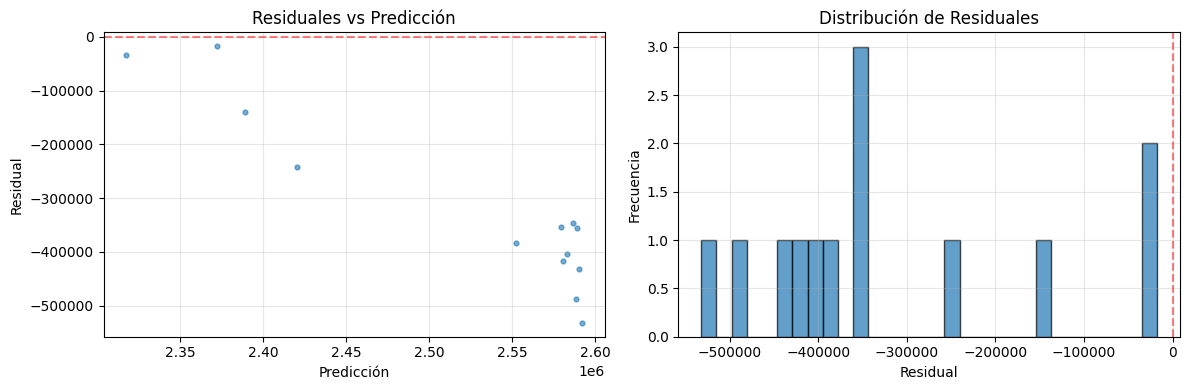

In [34]:
res = y_test_original - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuales vs Predicción
axes[0].scatter(y_pred, res, s=12, alpha=0.6)
axes[0].axhline(0, ls="--", color='red', alpha=0.5)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuales vs Predicción")
axes[0].grid(True, alpha=0.3)

# Histograma de residuales
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, ls="--", color='red', alpha=0.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuales")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Conclusiones

Este modelo LSTM combina **feature selection** (60→12 features) con **variables del LLM** (dataset_llm_fs_top60_+2.csv), buscando aprovechar información de sentimiento político y menciones de eventos.

### Resultados Obtenidos

```
RMSE Test:     355,591
R²:            -22.16
Error relativo: 16.17%
```

### Comparación con Otros Modelos LSTM

| Modelo | Dataset | Features | RMSE Test | R² | Error Rel |
|--------|---------|----------|-----------|-----|-----------|
| **LSTM base** | v2 | 60 | 231,359 | -8.80 | 10.52% |
| **LSTM + FS** | v2 | 12 | 228,287 | -8.55 | 10.38% |
| LSTM LLM | llm | 60 | 287,824 | -14.17 | 13.09% |
| **LSTM FS + LLM** | llm | 12 | **355,591** | **-22.16** | **16.17%** |

### Resultado: PEOR MODELO DE TODOS LOS EXPERIMENTOS

Este modelo obtuvo los **peores resultados de todos los modelos LSTM y de todos los experimentos con ML en general**:

- **56% peor** que LSTM base (355k vs 231k RMSE)
- **24% peor** que LSTM LLM sin FS (355k vs 288k RMSE)
- **R² catastrófico de -22.16** (el peor de todos los modelos probados)
- **Error relativo del 16.17%** (completamente inaceptable)

### ¿Por Qué Fracasó Tan Severamente?

#### 1. Doble Problema: Feature Selection + Variables LLM

**Feature selection ELIMINÓ variables tradicionales útiles**:
- El selector RF eligió 3/12 features del LLM (gobernanza_mean, sector_Educación_prop_true_lag1, bonos_soberanos_mean_lag2)
- Descartó 57/60 features, incluyendo variables macro importantes
- Quedaron pocas variables tradicionales para contrapesar el ruido del LLM

**Variables LLM agregaron ruido sin contexto suficiente**:
- Con solo 58 secuencias de entrenamiento, el LSTM no puede aprender patrones complejos de sentimiento
- Variables binarias/categóricas del LLM (menciones Trump, INDEC, etc.) son muy ruidosas para series temporales cortas
- El modelo memorizó correlaciones espurias entre menciones políticas y MERVAL

#### 2. LSTM No Puede Filtrar Features Ruidosas

A diferencia de **LightGBM LLM + FS** (RMSE 239k, R² -6.86) que:
- ✓ Puede ignorar features irrelevantes mediante feature importance en cada split
- ✓ Construye árboles que naturalmente hacen selección implícita
- ✓ Benefició de variables LLM (8/12 features seleccionadas fueron del LLM)

**LSTM procesa todas las features por igual**:
- ✗ No tiene mecanismo de atención para ignorar variables ruidosas
- ✗ Propaga información de TODAS las features en cada timestep
- ✗ Con datos limitados, aprende patrones incorrectos de las variables LLM

#### 3. Combinación Letal: Pocos Datos + Features Ruidosas + Modelo Complejo

```
58 secuencias × 3 timesteps × 12 features = 2,088 valores de entrada
vs.
1,929 parámetros del modelo

Ratio: ~1.08 valores por parámetro
```

Este ratio es **extremadamente bajo** para redes neuronales:
- Se necesitan típicamente 10-100+ valores por parámetro
- Con ratio ~1, el modelo memoriza el conjunto de entrenamiento
- Las variables ruidosas del LLM empeoraron este overfitting

### Features Seleccionadas

Las 12 features seleccionadas incluyeron:

**Variables tradicionales (9/12)**:
- merval_cierre, merval_apertura_std20, merval_cierre_std20, merval_maximo
- tc_mayorista_std20, tc_minorista_std20
- emae_tendencia_ciclo_ma_5, emae_tendencia_ciclo_lag2
- badlar_ma_5, inflacion_lag2, tasa_prestamos_personales_ma_3

**Variables LLM (3/12)**:
- gobernanza_mean
- sector_Educación_prop_true_lag1
- bonos_soberanos_mean_lag2

El selector eligió pocas variables LLM, sugiriendo que **incluso Random Forest las considera menos predictivas** en este dataset.

### Paradoja del Desempeño

**¿Por qué LightGBM LLM + FS fue el mejor modelo (239k RMSE) y LSTM FS LLM el peor (356k RMSE)?**

| Aspecto | LightGBM | LSTM |
|---------|----------|------|
| **Manejo de features ruidosas** | Ignora mediante splits | Procesa todas por igual |
| **Selección implícita** | En cada árbol | No tiene |
| **Requerimiento de datos** | 100-300 obs | 5,000+ secuencias |
| **Robustez a ruido** | Alta (ensemble) | Baja (aprende patrones espurios) |
| **Resultado con LLM** | ✓ Mejora | ✗ Empeora severamente |

### Veredicto Final

**Este modelo es completamente inviable y confirma que:**

1. **Variables LLM NO funcionan con LSTM en datasets pequeños**
   - LightGBM puede beneficiarse (mejora ~9%)
   - LSTM se perjudica severamente (empeora ~24-56%)

2. **Feature selection empeoró el problema**
   - Con 60 features al menos había variables tradicionales sólidas
   - Con 12 features, las 3 del LLM tuvieron peso desproporcionado

3. **La arquitectura importa**
   - Modelos con selección implícita (árboles) manejan mejor variables LLM
   - Modelos que procesan todo (LSTM) sufren con ruido

**Para predicción del MERVAL con este dataset:**
- ✓ Usar LightGBM LLM + FS (mejor modelo: 239k RMSE)
- ✓ O ARIMA simple (176k RMSE, modelo más simple)
- ✗ NUNCA usar LSTM con variables LLM en datasets <1,000 observaciones

**Este experimento demuestra que más complejidad (LSTM) + más features (LLM) NO garantiza mejor desempeño. Con datos limitados, simplicidad y selectividad son superiores.**